In [1]:
"""
变速拖船调度模型Gurobi求解器 (Model 2: MTRSP-VS)
Variable Speed Tugboat Scheduling Solver with Gurobi
特点：服务/转场速度独立优化 + 双线性项线性化
"""

import json
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import time


class VariableSpeedTugboatSolver:
    """变速拖船调度求解器"""
    
    def __init__(self, instance_data: dict):
        """初始化求解器"""
        self.instance = instance_data
        self.metadata = instance_data['metadata']
        self.tasks = instance_data['tasks']
        self.tugboats = instance_data['tugboats']
        self.base_loc = instance_data['base_location']
        self.speed_levels = instance_data['speed_levels']
        self.distance_matrix = instance_data['distance_matrix']
        
        self.n = len(self.tasks)  # 任务数
        self.K = len(self.tugboats)  # 拖船数
        self.L = list(self.speed_levels.keys())  # 速度档位
        self.M = self.metadata['M']
        self.T_max = self.metadata['T_max']
        self.W = self.metadata['W']
        self.v_medium = 10.0  # 基准速度
        
        # 动态计算时间和燃油系数矩阵（按需计算，不保存）
        print("  正在计算速度相关矩阵...")
        self.service_time_matrix = self._compute_service_time_matrix()
        self.transit_time_matrix = self._compute_transit_time_matrix()
        self.service_fuel_coef = self._compute_service_fuel_coef()
        self.transit_fuel_coef = self._compute_transit_fuel_coef()
        print("  矩阵计算完成")
        
        self.model = None
        self.solution = None
    
    def _compute_service_time_matrix(self):
        """动态计算服务时间矩阵 T^ℓ_s = d_s / v^ℓ"""
        service_time_matrix = {}
        for s in range(1, self.n + 1):
            service_distance = self.tasks[str(s)]['service_distance']
            for level, params in self.speed_levels.items():
                key = f'{s}_{level}'
                service_time_matrix[key] = service_distance / params['speed']
        return service_time_matrix
    
    def _compute_transit_time_matrix(self):
        """动态计算转场时间矩阵 t^ℓ_ij = d_ij / v^ℓ"""
        transit_time_matrix = {}
        for key, distance in self.distance_matrix.items():
            for level, params in self.speed_levels.items():
                transit_key = f'{key}_{level}'
                transit_time_matrix[transit_key] = distance / params['speed']
        return transit_time_matrix
    
    def _compute_service_fuel_coef(self):
        """动态计算服务燃油系数 ψ^kℓ_s = α_k · HP_k · d_s · (v^ℓ)^2 / (v_medium)^3"""
        service_fuel_coef = {}
        for s in range(1, self.n + 1):
            service_distance = self.tasks[str(s)]['service_distance']
            for k in range(1, self.K + 1):
                tug = self.tugboats[str(k)]
                for level, params in self.speed_levels.items():
                    key = f'{s}_{k}_{level}'
                    coef = (tug['alpha'] * tug['horsepower'] * service_distance * 
                           params['speed']**2 / self.v_medium**3)
                    service_fuel_coef[key] = coef
        return service_fuel_coef
    
    def _compute_transit_fuel_coef(self):
        """动态计算转场燃油系数 φ^kℓ_ij = β_k · HP_k · d_ij · (v^ℓ)^2 / (v_medium)^3"""
        transit_fuel_coef = {}
        for dist_key, distance in self.distance_matrix.items():
            for k in range(1, self.K + 1):
                tug = self.tugboats[str(k)]
                for level, params in self.speed_levels.items():
                    key = f'{dist_key}_{k}_{level}'
                    coef = (tug['beta'] * tug['horsepower'] * distance * 
                           params['speed']**2 / self.v_medium**3)
                    transit_fuel_coef[key] = coef
        return transit_fuel_coef
        
    def build_model(self):
        """构建Gurobi模型"""
        
        print(f"\n{'='*80}")
        print(f"构建变速模型 (MTRSP-VS): {self.metadata['name']}")
        print(f"{'='*80}\n")
        print(f"  任务数: {self.n}")
        print(f"  拖船数: {self.K}")
        print(f"  速度档位: {len(self.L)} ({', '.join(self.L)})")
        print(f"  难度: {self.metadata.get('difficulty', 'unknown')}")
        print(f"  惩罚权重W: {self.W}")
        
        # 创建模型
        self.model = gp.Model("MTRSP_VS")
        
        # ========== 决策变量 ==========
        
        # x[i,j,k]: 拖船k从节点i到节点j
        x = {}
        for k in range(1, self.K + 1):
            # 基地(0)到任务
            for j in range(1, self.n + 1):
                x[0, j, k] = self.model.addVar(vtype=GRB.BINARY, name=f'x_0_{j}_{k}')
            # 任务到任务
            for i in range(1, self.n + 1):
                for j in range(1, self.n + 1):
                    if i != j:
                        x[i, j, k] = self.model.addVar(vtype=GRB.BINARY, name=f'x_{i}_{j}_{k}')
            # 任务到基地(n+1)
            for i in range(1, self.n + 1):
                x[i, self.n + 1, k] = self.model.addVar(vtype=GRB.BINARY, name=f'x_{i}_{self.n+1}_{k}')
        
        # y[s,k]: 拖船k服务任务s
        y = {}
        for s in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                y[s, k] = self.model.addVar(vtype=GRB.BINARY, name=f'y_{s}_{k}')
        
        # z[s]: 任务s是否被选中执行
        z = {}
        for s in range(1, self.n + 1):
            z[s] = self.model.addVar(vtype=GRB.BINARY, name=f'z_{s}')
        
        # u[s,level]: 任务s选择服务速度档位level（新增）
        u = {}
        for s in range(1, self.n + 1):
            for level in self.L:
                u[s, level] = self.model.addVar(vtype=GRB.BINARY, name=f'u_{s}_{level}')
        
        # v[i,j,k,level]: 拖船k从i到j选择转场速度档位level（新增）
        v = {}
        for k in range(1, self.K + 1):
            # 基地到任务
            for j in range(1, self.n + 1):
                for level in self.L:
                    v[0, j, k, level] = self.model.addVar(vtype=GRB.BINARY, name=f'v_0_{j}_{k}_{level}')
            # 任务到任务
            for i in range(1, self.n + 1):
                for j in range(1, self.n + 1):
                    if i != j:
                        for level in self.L:
                            v[i, j, k, level] = self.model.addVar(vtype=GRB.BINARY, name=f'v_{i}_{j}_{k}_{level}')
            # 任务到基地
            for i in range(1, self.n + 1):
                for level in self.L:
                    v[i, self.n + 1, k, level] = self.model.addVar(vtype=GRB.BINARY, name=f'v_{i}_{self.n+1}_{k}_{level}')
        
        # w[s,k,level]: 辅助变量用于线性化 y[s,k] * u[s,level]
        w = {}
        for s in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                for level in self.L:
                    w[s, k, level] = self.model.addVar(vtype=GRB.BINARY, name=f'w_{s}_{k}_{level}')
        
        # tau[s]: 任务s的服务开始时间
        tau = {}
        for s in range(1, self.n + 1):
            tau[s] = self.model.addVar(vtype=GRB.CONTINUOUS, lb=0, name=f'tau_{s}')
        
        self.model.update()
        
        # ========== 双线性项线性化约束 ==========
        # w[s,k,level] = y[s,k] * u[s,level]
        
        for s in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                for level in self.L:
                    self.model.addConstr(w[s, k, level] <= y[s, k], name=f'Lin1_{s}_{k}_{level}')
                    self.model.addConstr(w[s, k, level] <= u[s, level], name=f'Lin2_{s}_{k}_{level}')
                    self.model.addConstr(w[s, k, level] >= y[s, k] + u[s, level] - 1, name=f'Lin3_{s}_{k}_{level}')
        
        # ========== 目标函数 ==========
        
        # 服务燃油消耗（线性化后）
        service_fuel = gp.LinExpr()
        for s in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                for level in self.L:
                    coef_key = f'{s}_{k}_{level}'
                    if coef_key in self.service_fuel_coef:
                        service_fuel += w[s, k, level] * self.service_fuel_coef[coef_key]
        
        # 转场燃油消耗
        transit_fuel = gp.LinExpr()
        for k in range(1, self.K + 1):
            # 基地到任务
            for j in range(1, self.n + 1):
                for level in self.L:
                    coef_key = f'0_{j}_{k}_{level}'
                    if coef_key in self.transit_fuel_coef:
                        transit_fuel += v[0, j, k, level] * self.transit_fuel_coef[coef_key]
            # 任务到任务
            for i in range(1, self.n + 1):
                for j in range(1, self.n + 1):
                    if i != j:
                        for level in self.L:
                            coef_key = f'{i}_{j}_{k}_{level}'
                            if coef_key in self.transit_fuel_coef:
                                transit_fuel += v[i, j, k, level] * self.transit_fuel_coef[coef_key]
            # 任务到基地
            for i in range(1, self.n + 1):
                for level in self.L:
                    coef_key = f'{i}_{self.n+1}_{k}_{level}'
                    if coef_key in self.transit_fuel_coef:
                        transit_fuel += v[i, self.n + 1, k, level] * self.transit_fuel_coef[coef_key]
        
        # 未完成任务惩罚
        penalty = gp.LinExpr()
        for s in range(1, self.n + 1):
            penalty += (1 - z[s])
        
        # 总目标函数
        obj = service_fuel + transit_fuel + self.W * penalty
        self.model.setObjective(obj, GRB.MINIMIZE)
        
        # ========== 约束条件 ==========
        
        # C1: 拖船数量约束
        for s in range(1, self.n + 1):
            task = self.tasks[str(s)]
            gamma_s = task['num_tugs_needed']
            self.model.addConstr(
                gp.quicksum(y[s, k] for k in range(1, self.K + 1)) <= gamma_s * z[s],
                name=f'C1_task_{s}'
            )
        
        # C2: 马力需求约束
        for s in range(1, self.n + 1):
            task = self.tasks[str(s)]
            h_min = task['min_horsepower']
            self.model.addConstr(
                gp.quicksum(y[s, k] * self.tugboats[str(k)]['horsepower'] 
                           for k in range(1, self.K + 1)) >= h_min * z[s],
                name=f'C2_task_{s}'
            )
        
        # C3: 每艘拖船最多从基地出发一次
        for k in range(1, self.K + 1):
            self.model.addConstr(
                gp.quicksum(x[0, j, k] for j in range(1, self.n + 1)) <= 1,
                name=f'C3_tug_{k}'
            )
        
        # C4: 每艘拖船最多返回基地一次
        for k in range(1, self.K + 1):
            self.model.addConstr(
                gp.quicksum(x[i, self.n + 1, k] for i in range(1, self.n + 1)) <= 1,
                name=f'C4_tug_{k}'
            )
        
        # C5: 流守恒
        for j in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                inflow = gp.quicksum(x[i, j, k] for i in range(0, self.n + 1) if (i, j, k) in x)
                outflow = gp.quicksum(x[j, i, k] for i in range(1, self.n + 2) if (j, i, k) in x)
                self.model.addConstr(inflow == outflow, name=f'C5_task_{j}_tug_{k}')
        
        # C6: 服务指示变量关联
        for s in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                self.model.addConstr(
                    y[s, k] == gp.quicksum(x[i, s, k] for i in range(0, self.n + 1) if (i, s, k) in x),
                    name=f'C6_task_{s}_tug_{k}'
                )
        
        # C7: 转场速度选择约束（新增）
        for k in range(1, self.K + 1):
            # 基地到任务
            for j in range(1, self.n + 1):
                self.model.addConstr(
                    gp.quicksum(v[0, j, k, level] for level in self.L) == x[0, j, k],
                    name=f'C7_0_{j}_{k}'
                )
            # 任务到任务
            for i in range(1, self.n + 1):
                for j in range(1, self.n + 1):
                    if i != j:
                        self.model.addConstr(
                            gp.quicksum(v[i, j, k, level] for level in self.L) == x[i, j, k],
                            name=f'C7_{i}_{j}_{k}'
                        )
            # 任务到基地
            for i in range(1, self.n + 1):
                self.model.addConstr(
                    gp.quicksum(v[i, self.n + 1, k, level] for level in self.L) == x[i, self.n + 1, k],
                    name=f'C7_{i}_{self.n+1}_{k}'
                )
        
        # C8: 服务速度选择约束（新增）
        for s in range(1, self.n + 1):
            self.model.addConstr(
                gp.quicksum(u[s, level] for level in self.L) == z[s],
                name=f'C8_task_{s}'
            )
        
        # C9: 时间窗约束
        for s in range(1, self.n + 1):
            task = self.tasks[str(s)]
            a_s, b_s = task['time_window']
            self.model.addConstr(tau[s] >= a_s * z[s], name=f'C9_lower_{s}')
            self.model.addConstr(tau[s] <= b_s + self.M * (1 - z[s]), name=f'C9_upper_{s}')
        
        # C10: 计划期约束（含速度依赖的服务时间）
        for s in range(1, self.n + 1):
            service_time_expr = gp.LinExpr()
            for level in self.L:
                time_key = f'{s}_{level}'
                if time_key in self.service_time_matrix:
                    service_time_expr += u[s, level] * self.service_time_matrix[time_key]
            
            self.model.addConstr(
                tau[s] + service_time_expr <= self.T_max + self.M * (1 - z[s]),
                name=f'C10_task_{s}'
            )
        
        # C11: 从基地出发的时间约束
        for j in range(1, self.n + 1):
            for k in range(1, self.K + 1):
                time_expr = gp.LinExpr()
                for level in self.L:
                    time_key = f'0_{j}_{level}'
                    if time_key in self.transit_time_matrix:
                        time_expr += v[0, j, k, level] * self.transit_time_matrix[time_key]
                
                self.model.addConstr(
                    tau[j] >= time_expr - self.M * (1 - x[0, j, k]),
                    name=f'C11_task_{j}_tug_{k}'
                )
        
        # C12: 任务间时间传递约束
        for i in range(1, self.n + 1):
            for j in range(1, self.n + 1):
                if i != j:
                    for k in range(1, self.K + 1):
                        # 任务i的服务时间
                        service_time_i = gp.LinExpr()
                        for level in self.L:
                            time_key = f'{i}_{level}'
                            if time_key in self.service_time_matrix:
                                service_time_i += u[i, level] * self.service_time_matrix[time_key]
                        
                        # i到j的转场时间
                        transit_time_ij = gp.LinExpr()
                        for level in self.L:
                            time_key = f'{i}_{j}_{level}'
                            if time_key in self.transit_time_matrix:
                                transit_time_ij += v[i, j, k, level] * self.transit_time_matrix[time_key]
                        
                        self.model.addConstr(
                            tau[j] >= tau[i] + service_time_i + transit_time_ij - self.M * (1 - x[i, j, k]),
                            name=f'C12_{i}_{j}_{k}'
                        )
        
        # C13: 燃油容量约束（线性化后）
        for k in range(1, self.K + 1):
            tug = self.tugboats[str(k)]
            fuel_usage = gp.LinExpr()
            
            # 服务燃油
            for s in range(1, self.n + 1):
                for level in self.L:
                    coef_key = f'{s}_{k}_{level}'
                    if coef_key in self.service_fuel_coef:
                        fuel_usage += w[s, k, level] * self.service_fuel_coef[coef_key]
            
            # 转场燃油
            # 基地到任务
            for j in range(1, self.n + 1):
                for level in self.L:
                    coef_key = f'0_{j}_{k}_{level}'
                    if coef_key in self.transit_fuel_coef:
                        fuel_usage += v[0, j, k, level] * self.transit_fuel_coef[coef_key]
            # 任务到任务
            for i in range(1, self.n + 1):
                for j in range(1, self.n + 1):
                    if i != j:
                        for level in self.L:
                            coef_key = f'{i}_{j}_{k}_{level}'
                            if coef_key in self.transit_fuel_coef:
                                fuel_usage += v[i, j, k, level] * self.transit_fuel_coef[coef_key]
            # 任务到基地
            for i in range(1, self.n + 1):
                for level in self.L:
                    coef_key = f'{i}_{self.n+1}_{k}_{level}'
                    if coef_key in self.transit_fuel_coef:
                        fuel_usage += v[i, self.n + 1, k, level] * self.transit_fuel_coef[coef_key]
            
            self.model.addConstr(fuel_usage <= tug['fuel_capacity'], name=f'C13_tug_{k}')
        
        # 保存变量
        self.x = x
        self.y = y
        self.z = z
        self.u = u
        self.v = v
        self.w = w
        self.tau = tau
        
        print(f"\n模型构建完成！")
        print(f"  变量数: {self.model.NumVars}")
        print(f"  约束数: {self.model.NumConstrs}")
    
    def solve(self, time_limit=3600, mip_gap=0.01, threads=4):
        """求解模型"""
        
        print(f"\n{'='*80}")
        print(f"开始求解")
        print(f"{'='*80}\n")
        
        # 设置Gurobi参数
        self.model.setParam('OutputFlag', 1)
        self.model.setParam('TimeLimit', time_limit)
        self.model.setParam('MIPGap', mip_gap)
        self.model.setParam('Threads', threads)
        self.model.setParam('MIPFocus', 1)
        
        # 求解
        start_time = time.time()
        self.model.optimize()
        solve_time = time.time() - start_time
        
        # 检查求解状态
        if self.model.Status == GRB.OPTIMAL:
            print(f"\n✓ 找到最优解！")
            return self._extract_solution(solve_time)
        elif self.model.Status == GRB.TIME_LIMIT:
            if self.model.SolCount > 0:
                print(f"\n⚠ 达到时间限制，返回当前最优解")
                return self._extract_solution(solve_time)
            else:
                print(f"\n❌ 达到时间限制，未找到可行解")
                return False
        elif self.model.Status == GRB.INFEASIBLE:
            print(f"\n❌ 模型不可行")
            self.model.computeIIS()
            self.model.write("model2_infeasible.ilp")
            return False
        else:
            print(f"\n❌ 求解失败，状态码: {self.model.Status}")
            return False
    
    def _extract_solution(self, solve_time):
        """提取解"""
        
        # 统计完成的任务
        completed_tasks = []
        uncompleted_tasks = []
        
        for s in range(1, self.n + 1):
            if self.z[s].X > 0.5:
                completed_tasks.append(s)
            else:
                uncompleted_tasks.append(s)
        
        completion_rate = len(completed_tasks) / self.n * 100
        
        # 提取任务-拖船服务关系
        task_assignments = {}
        for s in completed_tasks:
            assigned_tugs = []
            for k in range(1, self.K + 1):
                if self.y[s, k].X > 0.5:
                    assigned_tugs.append(k)
            task_assignments[s] = assigned_tugs
        
        # 提取服务速度选择
        service_speeds = {}
        for s in completed_tasks:
            for level in self.L:
                if self.u[s, level].X > 0.5:
                    service_speeds[s] = level
                    break
        
        # 提取拖船路径和转场速度
        routes = {k: [] for k in range(1, self.K + 1)}
        transit_speeds = {k: [] for k in range(1, self.K + 1)}
        
        for k in range(1, self.K + 1):
            # 从基地出发
            for j in range(1, self.n + 1):
                if (0, j, k) in self.x and self.x[0, j, k].X > 0.5:
                    current = j
                    routes[k].append(current)
                    
                    # 记录转场速度
                    for level in self.L:
                        if self.v[0, j, k, level].X > 0.5:
                            transit_speeds[k].append(('base', j, level))
                            break
                    
                    # 跟踪路径
                    while current <= self.n:
                        found_next = False
                        for next_node in range(1, self.n + 2):
                            if next_node != current and (current, next_node, k) in self.x:
                                if self.x[current, next_node, k].X > 0.5:
                                    if next_node <= self.n:
                                        routes[k].append(next_node)
                                    
                                    # 记录转场速度
                                    for level in self.L:
                                        if self.v[current, next_node, k, level].X > 0.5:
                                            dest = 'base' if next_node == self.n + 1 else next_node
                                            transit_speeds[k].append((current, dest, level))
                                            break
                                    
                                    current = next_node
                                    found_next = True
                                    break
                        if not found_next:
                            break
        
        # 计算燃油消耗
        total_fuel = self.model.ObjVal - self.W * len(uncompleted_tasks)
        
        self.solution = {
            'status': 'optimal' if self.model.Status == GRB.OPTIMAL else 'feasible',
            'objective': self.model.ObjVal,
            'fuel_consumption': total_fuel,
            'penalty': self.W * len(uncompleted_tasks),
            'mip_gap': self.model.MIPGap * 100,
            'solve_time': solve_time,
            'completed_tasks': completed_tasks,
            'uncompleted_tasks': uncompleted_tasks,
            'completion_rate': completion_rate,
            'routes': routes,
            'task_times': {s: self.tau[s].X for s in completed_tasks},
            'task_assignments': task_assignments,
            'service_speeds': service_speeds,
            'transit_speeds': transit_speeds
        }
        
        return True
    
    def print_solution(self):
        """打印解的详细信息"""
        
        if not self.solution:
            print("❌ 没有可用的解")
            return
        
        print(f"\n{'='*80}")
        print(f"求解结果 - 变速优化模型")
        print(f"{'='*80}\n")
        
        print(f"【目标函数值】")
        print(f"  总目标值: {self.solution['objective']:.2f}")
        print(f"  燃油消耗: {self.solution['fuel_consumption']:.2f} kg")
        print(f"  惩罚项: {self.solution['penalty']:.2f}")
        print(f"  MIP Gap: {self.solution['mip_gap']:.2f}%")
        print(f"  求解时间: {self.solution['solve_time']:.2f} 秒")
        
        print(f"\n【任务完成情况】")
        print(f"  完成任务数: {len(self.solution['completed_tasks'])}/{self.n}")
        print(f"  完成率: {self.solution['completion_rate']:.1f}%")
        
        if self.solution['uncompleted_tasks']:
            print(f"  未完成任务: {self.solution['uncompleted_tasks']}")
        
        print(f"\n【拖船路径与速度选择】")
        for k, route in self.solution['routes'].items():
            if route:
                tug = self.tugboats[str(k)]
                route_str = ' → '.join([f"T{s}" for s in route])
                print(f"\n  拖船{k} ({tug['name']}): 基地 → {route_str} → 基地")
                
                # 显示转场速度
                print(f"    转场速度:")
                for origin, dest, speed in self.solution['transit_speeds'][k]:
                    origin_str = '基地' if origin == 'base' else f'T{origin}'
                    dest_str = '基地' if dest == 'base' else f'T{dest}'
                    speed_value = self.speed_levels[speed]['speed']
                    print(f"      {origin_str} → {dest_str}: {speed} ({speed_value}节)")
        
        print(f"\n【任务时间安排与速度选择】")
        for s in sorted(self.solution['task_times'].keys()):
            task = self.tasks[str(s)]
            start_time = self.solution['task_times'][s]
            
            # 获取服务速度和时长
            service_speed = self.solution['service_speeds'][s]
            speed_value = self.speed_levels[service_speed]['speed']
            time_key = f'{s}_{service_speed}'
            service_time = self.service_time_matrix[time_key]
            end_time = start_time + service_time
            
            window = task['time_window']
            tugs = self.solution['task_assignments'][s]
            tug_names = [self.tugboats[str(k)]['name'] for k in tugs]
            
            print(f"  任务{s}: 时间窗[{window[0]:.1f}, {window[1]:.1f}] → "
                  f"实际{start_time:.2f}h - {end_time:.2f}h")
            print(f"         服务速度: {service_speed} ({speed_value}节), "
                  f"服务时长: {service_time:.2f}h")
            print(f"         服务拖船: {tugs} ({', '.join(tug_names)})")
        
        print(f"\n【速度选择统计】")
        speed_stats = {level: 0 for level in self.L}
        for speed in self.solution['service_speeds'].values():
            speed_stats[speed] += 1
        
        print(f"  服务速度分布:")
        for level in self.L:
            count = speed_stats[level]
            percentage = count / len(self.solution['completed_tasks']) * 100 if self.solution['completed_tasks'] else 0
            speed_value = self.speed_levels[level]['speed']
            print(f"    {level:8s} ({speed_value:4.1f}节): {count:3d}次 ({percentage:5.1f}%)")
    
    def visualize_solution(self, save_path=None):
        """可视化解（Gantt图）"""
        
        if not self.solution:
            print("❌ 没有可用的解")
            return
        
        fig, ax = plt.subplots(figsize=(16, max(6, self.K * 0.6)))
        
        # 颜色映射
        colors = plt.cm.Set3(np.linspace(0, 1, self.n))
        speed_colors = {'slow': '#90EE90', 'medium': '#FFD700', 'fast': '#FF6B6B'}
        
        # 绘制每艘拖船的时间线
        for k in range(1, self.K + 1):
            y_pos = k
            
            # 绘制服务任务
            for s in self.solution['routes'][k]:
                if s in self.solution['task_times']:
                    start = self.solution['task_times'][s]
                    service_speed = self.solution['service_speeds'][s]
                    time_key = f'{s}_{service_speed}'
                    duration = self.service_time_matrix[time_key]
                    
                    # 任务矩形
                    rect = Rectangle((start, y_pos - 0.4), duration, 0.8,
                                   facecolor=colors[s-1], edgecolor='black',
                                   linewidth=1.5, alpha=0.8)
                    ax.add_patch(rect)
                    
                    # 任务标签
                    ax.text(start + duration/2, y_pos, f'T{s}',
                           ha='center', va='center', fontsize=9, fontweight='bold')
                    
                    # 速度标签
                    speed_value = self.speed_levels[service_speed]['speed']
                    ax.text(start + duration/2, y_pos - 0.25, f'{speed_value:.0f}kn',
                           ha='center', va='top', fontsize=7, 
                           color=speed_colors.get(service_speed, 'gray'))
        
        # 设置图表
        ax.set_xlim(0, self.T_max)
        ax.set_ylim(0.5, self.K + 0.5)
        ax.set_xlabel('Time (hours)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Tugboats', fontsize=12, fontweight='bold')
        ax.set_yticks(range(1, self.K + 1))
        ax.set_yticklabels([self.tugboats[str(k)]['name'] for k in range(1, self.K + 1)])
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=speed_colors['slow'], label='Slow (8 kn)'),
            Patch(facecolor=speed_colors['medium'], label='Medium (10 kn)'),
            Patch(facecolor=speed_colors['fast'], label='Fast (12 kn)')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
        
        title = (f"{self.metadata['name']} - Variable Speed Optimization\n"
                f"Completion Rate: {self.solution['completion_rate']:.1f}%")
        ax.set_title(title, fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\n✓ 可视化已保存: {save_path}")
        
        plt.show()


def load_instance(filepath: str) -> dict:
    """加载实例数据"""
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)


变速拖船调度模型 (MTRSP-VS) Gurobi求解器
  正在计算速度相关矩阵...
  矩阵计算完成

构建变速模型 (MTRSP-VS): VS_X_100_20_v1

  任务数: 100
  拖船数: 20
  速度档位: 3 (slow, medium, fast)
  难度: extreme
  惩罚权重W: 100000.0
Set parameter LicenseID to value 2613782

模型构建完成！
  变量数: 816500
  约束数: 0

开始求解

Set parameter TimeLimit to value 1800
Set parameter MIPGap to value 0.01
Set parameter Threads to value 4
Set parameter MIPFocus to value 1
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-12450H, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 12 logical processors, using up to 4 threads

Optimize a model with 424660 rows, 816500 columns and 3865500 nonzeros
Model fingerprint: 0xc67b92e2
Variable types: 100 continuous, 816400 integer (816400 binary)
Coefficient statistics:
  Matrix range     [1e-02, 1e+04]
  Objective range  [2e+00, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]
Found heuristic solution: objective 1.

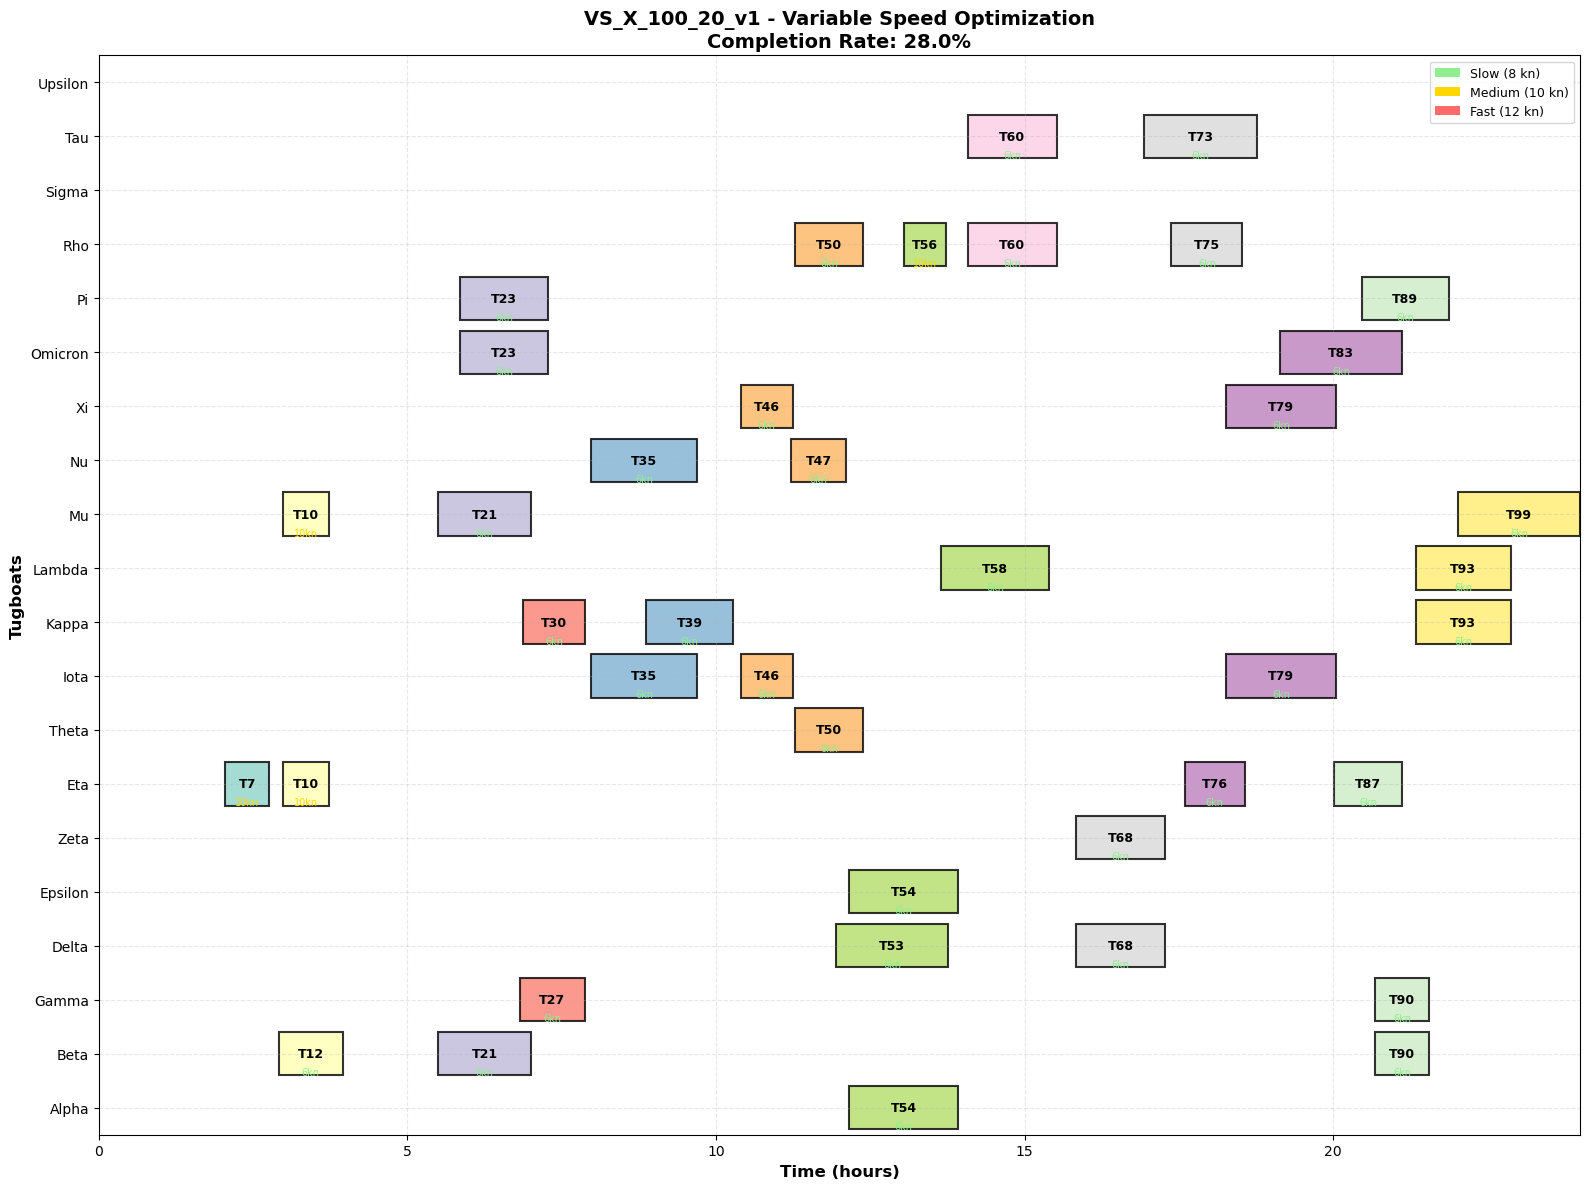

In [2]:
def main():
    """主函数 - 测试示例"""
    
    # 这里可以加载一个测试实例
    print("="*80)
    print("变速拖船调度模型 (MTRSP-VS) Gurobi求解器")
    print("="*80)
    instance = load_instance('instances_model2_vs/VS_X_100_20_v1.json')
    solver = VariableSpeedTugboatSolver(instance)
    solver.build_model()
    solver.solve(time_limit=1800, mip_gap=0.01)
    solver.print_solution()
    solver.visualize_solution(save_path='solution_model2.png')


if __name__ == "__main__":
    main()